<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day6/Day6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

학습 데이터: (400, 2)
검증 데이터: (100, 2)


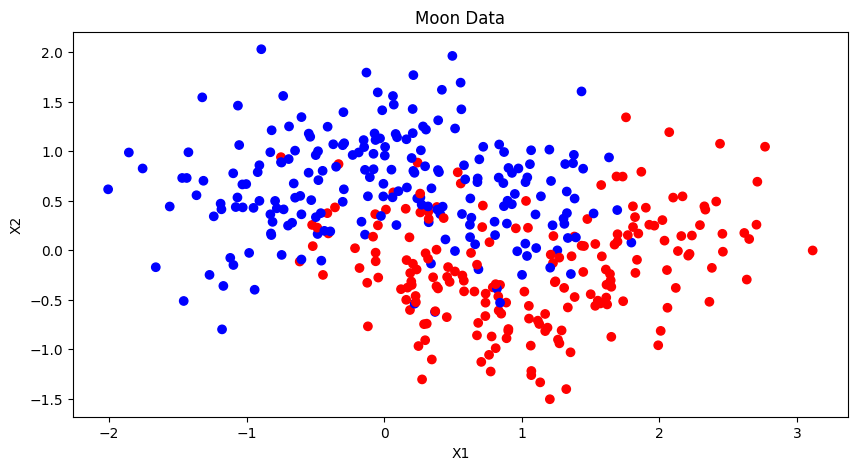

In [ ]:
# 1. 데이터 준비 (분류 : Moon 데이터셋)
# 반달 모양의 데이터 500개 생성 (약간의 노이즈 추가)
X, y = make_moons(n_samples=500, noise=0.4, random_state=42)

# 데이터 분할 (Train 80% / Validation 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습 데이터: {X_train.shape}")
print(f"검증 데이터: {X_val.shape}")

plt.figure(figsize=(10, 5))
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap = 'bwr')
plt.title('Moon Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


In [ ]:
# 2. 모델 설정
# 특성을 20차원까지 하여 모델을 복잡하게 만듬
poly_features = PolynomialFeatures(degree=20, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train)
X_val_poly = poly_features.transform(X_val)

# 스케일링 (학습 속도 향상)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_val_scaled = scaler.transform(X_val_poly)

# SGD Classifier
model = SGDClassifier(loss='log_loss', penalty=None, learning_rate='constant', eta0=0.01, random_state=42)

train_losses, val_losses = [],[]
epochs = 600
classes = np.unique(y) #[0,1]

In [ ]:
# 3. 반복 학습 (Epoch) 및 Loss 기록
print("\n 모델 학습 시작...")

for epoch in range(epochs):
  # 점진적 학습 (Partial Fit)
  model.partial_fit(X_train_scaled, y_train, classes=classes)

  # 확률 예측 (Predict Proba)
  y_train_prob = model.predict_proba(X_train_scaled)
  y_val_prob = model.predict_proba(X_val_scaled)

  # Loss 계산 (Log Loss = Cross Entropy)
  train_loss = log_loss(y_train, y_train_prob)
  val_loss = log_loss(y_val, y_val_prob)

  train_losses.append(train_loss)
  val_losses.append(val_loss)

print("학습 종료!")


 모델 학습 시작...
학습 종료!


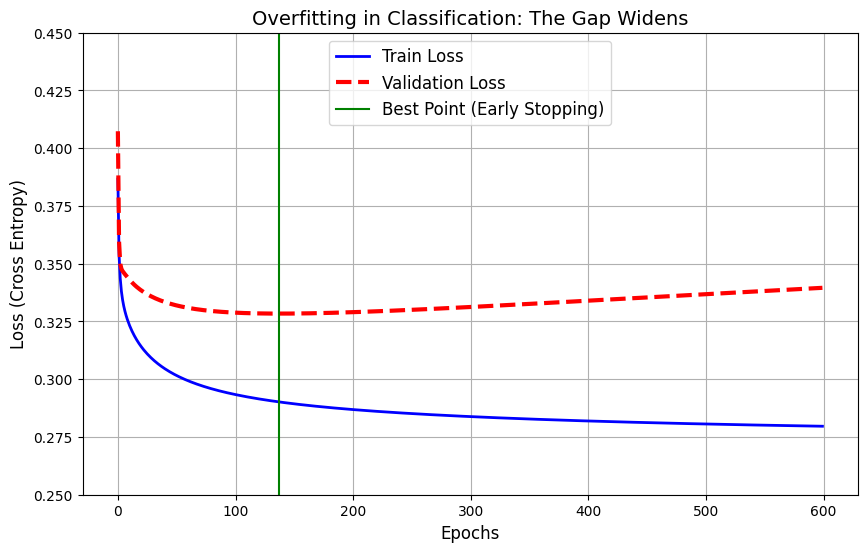

최적의 멈춤 지점: Epoch 137


In [ ]:
# 4. [주요 아웃풋] 과적합 시각화 리포트
plt.figure(figsize=(10,6))

# Train Loss (파란색)
plt.plot(train_losses, "b-", linewidth=2, label='Train Loss')
# Validation Loss (빨간색)
plt.plot(val_losses, "r--", linewidth=3, label='Validation Loss')

plt.axvline(x=np.argmin(val_losses), color='g', label="Best Point (Early Stopping)")
plt.legend(loc='upper center', fontsize=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Cross Entropy)', fontsize=12)
plt.title("Overfitting in Classification: The Gap Widens", fontsize=14)
plt.grid(True)
plt.ylim(0.25, 0.45)
plt.show()

print(f"최적의 멈춤 지점: Epoch {np.argmin(val_losses)}")

과적합이 일어나기 시작하는 지점인 Epoch 137을 도출. 최적의 모델을 얻을 수 있는 지점을 알아내고 과적합을 방지할 수 있다.